In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [55]:
dir_path = 'Fruit Freshness Dataset'
os.listdir(dir_path)

['Fruit Freshness Dataset']

['Apple', 'Banana', 'Strawberry']

In [56]:
strawberry_path = os.path.join(dir_path, 'Strawberry')
apple_path = os.path.join(dir_path, 'Apple')
banana_path = os.path.join(dir_path, 'Banana')

print(f"Strawberry directory: {strawberry_path}")
print(f"Apple directory: {apple_path}")
print(f"Banana directory: {banana_path}")

Strawberry directory: Fruit Freshness Dataset/Strawberry
Apple directory: Fruit Freshness Dataset/Apple
Banana directory: Fruit Freshness Dataset/Banana


In [100]:
import os

# Adjusting the base directory path to target the correct nested folder structure
# The dataset extracted into 'Fruit Freshness Dataset/Fruit Freshness Dataset/'
nested_dir_path = 'Fruit Freshness Dataset/Fruit Freshness Dataset'

# Update category paths pointing to the correct nested subfolders
strawberry_path = os.path.join(nested_dir_path, 'Strawberry')
apple_path = os.path.join(nested_dir_path, 'Apple')
banana_path = os.path.join(nested_dir_path, 'Banana')

try:
    print(f"Strawberry directory: {os.listdir(strawberry_path)}")
    print(f"Apple directory: {os.listdir(apple_path)}")
    print(f"Banana directory: {os.listdir(banana_path)}")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Verify the folder structure using os.listdir(nested_dir_path)")

Strawberry directory: ['Fresh', 'Rotten']
Apple directory: ['Fresh', 'Rotten']
Banana directory: ['Fresh', 'Rotten']


In [58]:
import os
import pandas as pd

# Define the correct base path targeting the nested directory structure
base_dataset_path = 'Fruit Freshness Dataset/Fruit Freshness Dataset'

image_paths = []
labels = []

# Traverse the fruit subdirectories and collect all image files
if os.path.exists(base_dataset_path):
    for root, dirs, files in os.walk(base_dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(root, file)
                image_paths.append(full_path)

                # Create a label based on the folder hierarchy (e.g., "Apple_Fresh" or "Apple")
                relative_path = os.path.relpath(full_path, base_dataset_path)
                path_parts = relative_path.split(os.sep)

                # If path is like 'Apple/Fresh/apple_1.jpg', label can be 'Apple_Fresh'
                if len(path_parts) >= 2:
                    label = "_".join(path_parts[:-1])
                else:
                    label = path_parts[0]
                labels.append(label)

# Populate the DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

print(f"Loaded {len(df)} images into the DataFrame.")
display(df.head())
if not df.empty:
    print("\nUnique labels found:", df['label'].unique())

Loaded 529 images into the DataFrame.


,image_path,label
0,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Fresh
1,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Fresh
2,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Fresh
3,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Fresh
4,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Fresh



Unique labels found: ['Banana_Fresh' 'Banana_Rotten' 'Apple_Fresh' 'Apple_Rotten'
 'Strawberry_Fresh' 'Strawberry_Rotten']


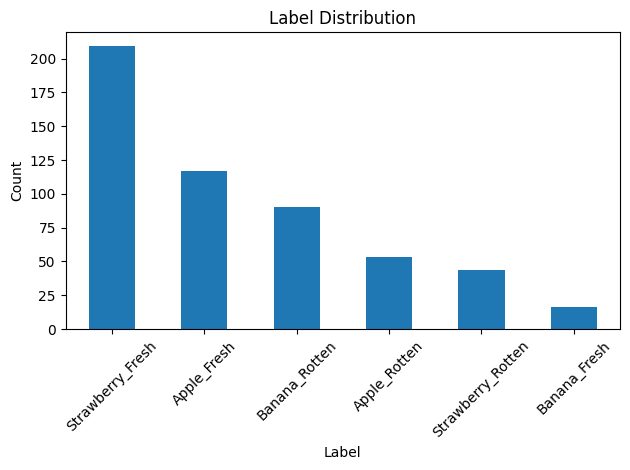

In [65]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Reconstruct df if it is currently empty in memory
if 'df' not in globals() or df.empty:
    base_dataset_path = 'Fruit Freshness Dataset/Fruit Freshness Dataset'
    image_paths = []
    labels = []
    if os.path.exists(base_dataset_path):
        for root, dirs, files in os.walk(base_dataset_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    full_path = os.path.join(root, file)
                    image_paths.append(full_path)
                    relative_path = os.path.relpath(full_path, base_dataset_path)
                    path_parts = relative_path.split(os.sep)
                    if len(path_parts) >= 2:
                        label = "_".join(path_parts[:-1])
                    else:
                        label = path_parts[0]
                    labels.append(label)
    df = pd.DataFrame({'image_path': image_paths, 'label': labels})

# Plot the label distribution
if not df.empty:
    df['label'].value_counts(ascending=False).plot(kind='bar', title='Label Distribution')
    plt.xticks(rotation=45)
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame is empty. Please ensure the dataset is extracted correctly.")

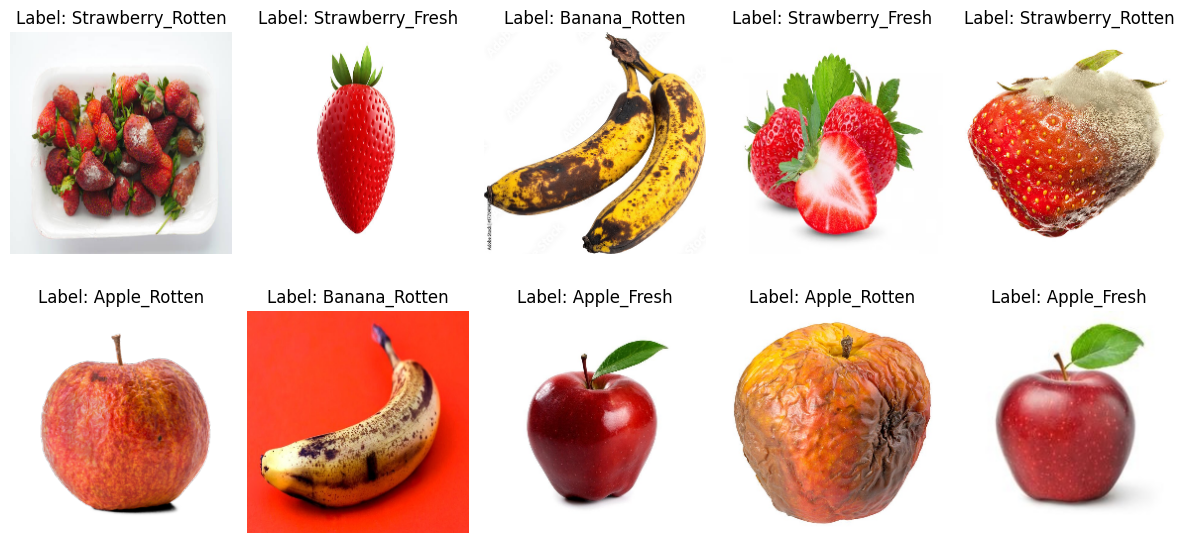

In [64]:
import cv2
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

# Reconstruct df if it is currently empty in memory
if 'df' not in globals() or df.empty:
    base_dataset_path = 'Fruit Freshness Dataset/Fruit Freshness Dataset'
    image_paths = []
    labels = []
    if os.path.exists(base_dataset_path):
        for root, dirs, files in os.walk(base_dataset_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    full_path = os.path.join(root, file)
                    image_paths.append(full_path)
                    relative_path = os.path.relpath(full_path, base_dataset_path)
                    path_parts = relative_path.split(os.sep)
                    if len(path_parts) >= 2:
                        label = "_".join(path_parts[:-1])
                    else:
                        label = path_parts[0]
                    labels.append(label)
    df = pd.DataFrame({'image_path': image_paths, 'label': labels})

if df.empty:
    print("Error: No images found. Please ensure the dataset is extracted correctly.")
else:
    labels = df['label'].unique()
    plt.figure(figsize=(12, 6))
    num_samples = min(10, len(df))

    for i in range(num_samples):
        random_index = random.randint(0, len(df) - 1)
        image_path = df.iloc[random_index]['image_path']
        label = df.iloc[random_index]['label']

        img = plt.imread(image_path).copy()
        resized_img = cv2.resize(img, (224, 224))
        plt.subplot(2, 5, i+1)
        plt.imshow(resized_img)
        plt.title(f"Label: {label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['image_path'], df['label'], test_size=0.2, random_state=42)

train_df = pd.DataFrame({'image_path': X_train, 'label': y_train})
test_df = pd.DataFrame({'image_path': X_test, 'label': y_test})


In [69]:
train_df.head()

,image_path,label
137,Fruit Freshness Dataset/Fruit Freshness Datase...,Apple_Fresh
525,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Rotten
416,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Fresh
371,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Fresh
69,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Rotten


In [71]:
train_df.shape

(423, 2)

In [72]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from sklearn.model_selection import train_test_split

train_augmentation_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

In [74]:
train_dataset = train_augmentation_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_dataset = test_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 423 validated image filenames belonging to 6 classes.
Found 106 validated image filenames belonging to 6 classes.


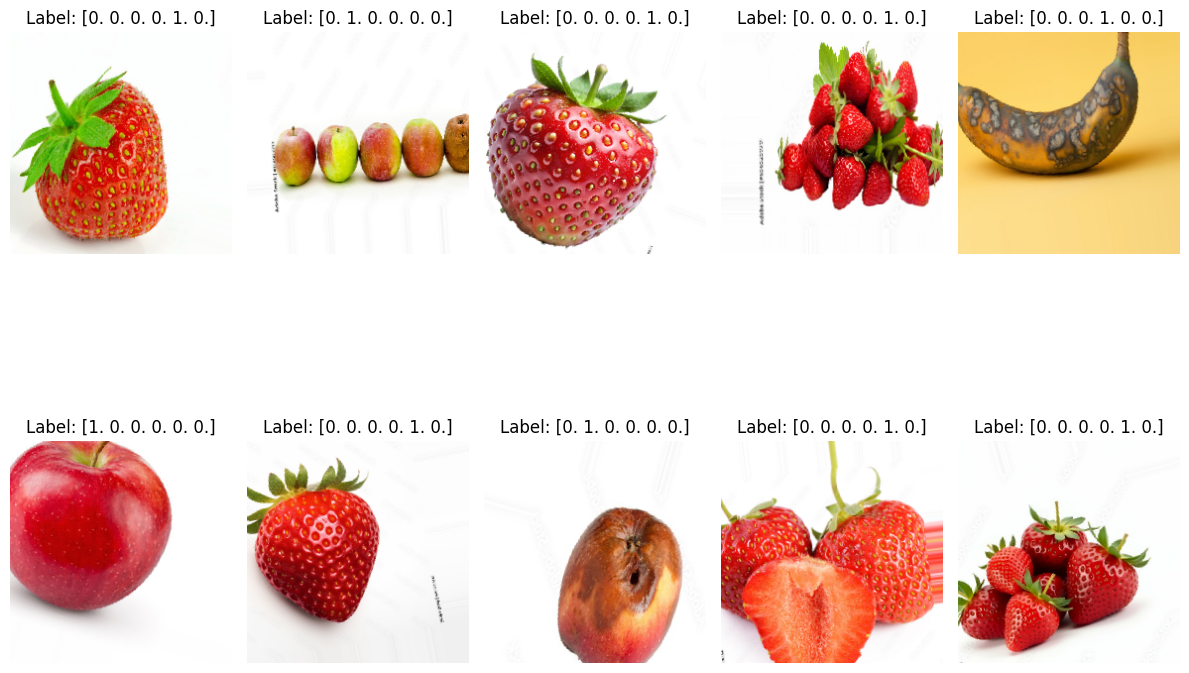

In [75]:
# Visualizing some train data augmented
images, labels = next(train_dataset)

plt.figure(figsize=(12, 10))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(images[i])
  plt.title(f"Label: {labels[i]}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [76]:
# Setting up callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input

model = Sequential([
    Input(shape=(224, 224, 3)),
    # First layer
    Conv2D(32, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    # Second layer
    Conv2D(64, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    # Third layer
    Conv2D(128, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='model')

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [89]:
model_history = model.fit(
    train_dataset,
    steps_per_epoch=len(train_dataset),
    validation_data=test_dataset,
    validation_steps=len(test_dataset),
    epochs=20,
    callbacks=[early_stopping, model_checkpoint, lr_scheduler]
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3381 - loss: 3.0821
Epoch 1: val_loss improved from None to 1.34486, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.3995 - loss: 2.0160 - val_accuracy: 0.4906 - val_loss: 1.3449 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5152 - loss: 1.2391
Epoch 2: val_loss improved from 1.34486 to 1.12377, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.5650 - loss: 1.1510 - val_accuracy: 0.5755 - val_loss: 1.1238 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6147 - loss: 0.9948
Epoch 3: val_loss improved from 1.12377 to 0.96973, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.6407 - loss:

In [91]:
def plot_history(history):
  acc = history.history['accuracy']
  loss = history.history['loss']

  val_acc = history.history['val_accuracy']
  val_loss = history.history['val_loss']

  epochs = range(len(acc))

  plt.figure(figsize=(12, 6))

  plt.subplot(2, 2, 1)
  plt.plot(epochs, acc, 'r', label='Training Accuracy')
  plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()

  plt.subplot(2, 2, 2)
  plt.plot(epochs, loss, 'r', label='Training Loss')
  plt.plot(epochs, val_loss, 'b', label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.legend()

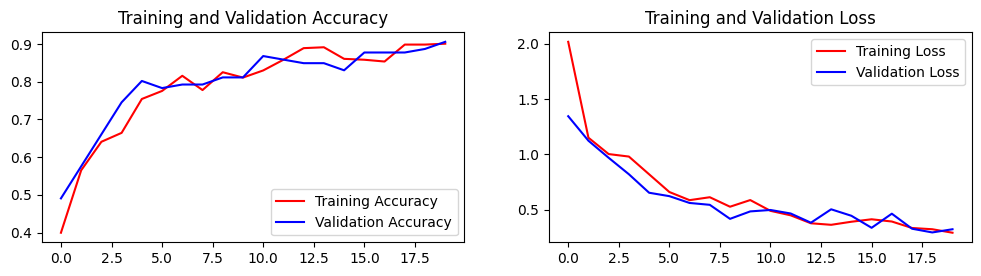

In [92]:
plot_history(model_history)

In [93]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 753ms/step - accuracy: 0.8868 - loss: 0.2963


[0.29626232385635376, 0.8867924809455872]

In [94]:
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')

preds = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 778ms/step


In [98]:
import numpy as np

class_indices = train_dataset.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

# Corrected prediction logic for multi-class classification
# We take the index of the class with the highest probability along axis 1
predicted_class_indices = np.argmax(preds, axis=1)
predicted_classes = [idx_to_class[idx] for idx in predicted_class_indices]

print("First 10 predicted class labels:")
for i, label in enumerate(predicted_classes[:10]):
    print(f"Image {i+1}: {label}")

test_df['predicted_label'] = predicted_classes
display(test_df.head(10))

First 10 predicted class labels:
Image 1: Apple_Fresh
Image 2: Strawberry_Fresh
Image 3: Apple_Rotten
Image 4: Strawberry_Fresh
Image 5: Strawberry_Fresh
Image 6: Banana_Rotten
Image 7: Apple_Rotten
Image 8: Strawberry_Fresh
Image 9: Strawberry_Rotten
Image 10: Banana_Rotten


,image_path,label,predicted_label
140,Fruit Freshness Dataset/Fruit Freshness Datase...,Apple_Fresh,Apple_Fresh
397,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Fresh,Strawberry_Fresh
6,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Fresh,Apple_Rotten
334,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Fresh,Strawberry_Fresh
322,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Fresh,Strawberry_Fresh
82,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Rotten,Banana_Rotten
225,Fruit Freshness Dataset/Fruit Freshness Datase...,Apple_Rotten,Apple_Rotten
495,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Rotten,Strawberry_Fresh
522,Fruit Freshness Dataset/Fruit Freshness Datase...,Strawberry_Rotten,Strawberry_Rotten
101,Fruit Freshness Dataset/Fruit Freshness Datase...,Banana_Rotten,Banana_Rotten


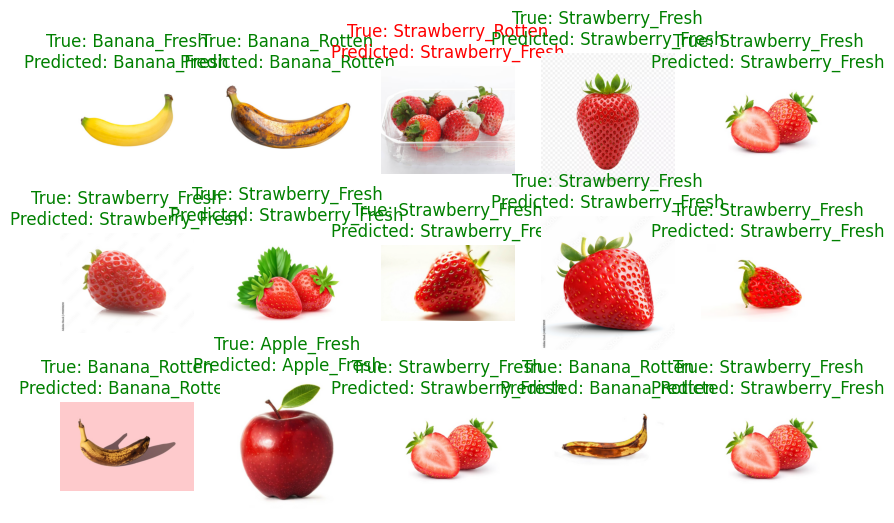

In [99]:
fig, ax = plt.subplots(3, 5, figsize=(10, 6))
ax = ax.ravel()

for i in range(15):
  idx = random.randint(0, len(test_df) - 1)
  image_path = test_df.iloc[idx]['image_path']
  true_label = test_df.iloc[idx]['label']
  predicted_label = test_df.iloc[idx]['predicted_label']

  if true_label == predicted_label:
    color = 'green'
  else:
    color = 'red'

  img = plt.imread(image_path)
  ax[i].imshow(img)
  ax[i].set_title(f"True: {true_label}\nPredicted: {predicted_label}", color=color)
  ax[i].axis('off')